# Heart Disease Prediction - Machine Learning Project

**Student Name:** [Your Name]

**Date:** 2024

---

## What is this project about?

In this project, I will build a machine learning model that can predict if a patient has heart disease based on their medical information. This is like a doctor using patient data to make a diagnosis.

---
# PHASE 1: Dataset Selection
---

## 1.1 About My Dataset

| Information | Details |
|-------------|---------|
| **Dataset Name** | Heart Disease UCI |
| **Source** | Kaggle (from UCI Machine Learning Repository) |
| **Rows** | 920 patients |
| **Columns** | 16 features |
| **Target Variable** | `num` (0 = no disease, 1-4 = has disease) |
| **Problem** | Predict if patient has heart disease |

### What do the columns mean?

- **age**: Patient's age in years
- **sex**: Male or Female
- **cp**: Chest pain type (typical angina, atypical angina, non-anginal, asymptomatic)
- **trestbps**: Resting blood pressure
- **chol**: Cholesterol level
- **fbs**: Fasting blood sugar (TRUE if > 120 mg/dl)
- **restecg**: ECG results
- **thalch**: Maximum heart rate achieved
- **exang**: Exercise induced angina (TRUE/FALSE)
- **oldpeak**: ST depression (a measure on ECG)
- **slope**: Slope of ST segment
- **ca**: Number of major vessels
- **thal**: Thalassemia type
- **num**: Target variable (0 = no disease, 1-4 = disease present)

In [15]:
# =====================================
# STEP 1: Import Libraries
# =====================================
# These are the tools we need for data analysis and machine learning

import pandas as pd        # For loading and handling data
import numpy as np         # For mathematical operations
import matplotlib.pyplot as plt  # For creating graphs
import seaborn as sns      # For prettier graphs

# Machine learning libraries from sklearn
from sklearn.model_selection import train_test_split  # To split data
from sklearn.preprocessing import StandardScaler, LabelEncoder  # To prepare data
from sklearn.linear_model import LogisticRegression    # Model 1
from sklearn.ensemble import RandomForestClassifier    # Model 2
from sklearn.svm import SVC                            # Model 3
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')  # Hide warning messages

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [16]:
# =====================================
# STEP 2: Load the Dataset
# =====================================
# Read the CSV file into a pandas DataFrame

df = pd.read_csv('heart_disease_uci.csv')

# Show the shape (rows, columns)
print(f"Dataset Shape: {df.shape}")
print(f"Number of patients: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

# Show first 5 rows
df.head()

Dataset Shape: (920, 16)
Number of patients: 920
Number of features: 16


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [17]:
# =====================================
# STEP 3: Basic Information About Data
# =====================================

# Check data types and missing values
print("Data Types and Missing Values:")
df.info()

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [18]:
# Statistical summary of numeric columns
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


---
# PHASE 2: Problem Definition
---

## 2.1 What Type of Machine Learning Problem is This?

This is a **Binary Classification** problem.

**Why?** Because we want to predict one of two outcomes:
- 0 = No heart disease
- 1 = Has heart disease

### My Target Variable

The original target `num` has values 0, 1, 2, 3, 4:
- 0 = No heart disease
- 1, 2, 3, 4 = Heart disease present (different severity levels)

I will convert this to binary:
- 0 stays as 0 (no disease)
- 1, 2, 3, 4 all become 1 (has disease)

### Why is this problem important?

1. Heart disease is a leading cause of death worldwide
2. Early detection can save lives
3. Machine learning can help doctors make better decisions
4. It can speed up diagnosis and reduce costs

In [19]:
# =====================================
# STEP 4: Create Binary Target Variable
# =====================================

# Create a new column 'target' where:
# - 0 means no heart disease (when num == 0)
# - 1 means has heart disease (when num > 0)

df['target'] = (df['num'] > 0).astype(int)

# Show the distribution
print("Target Variable Distribution:")
print(df['target'].value_counts())
print("\n0 = No Heart Disease, 1 = Has Heart Disease")

Target Variable Distribution:
target
1    509
0    411
Name: count, dtype: int64

0 = No Heart Disease, 1 = Has Heart Disease


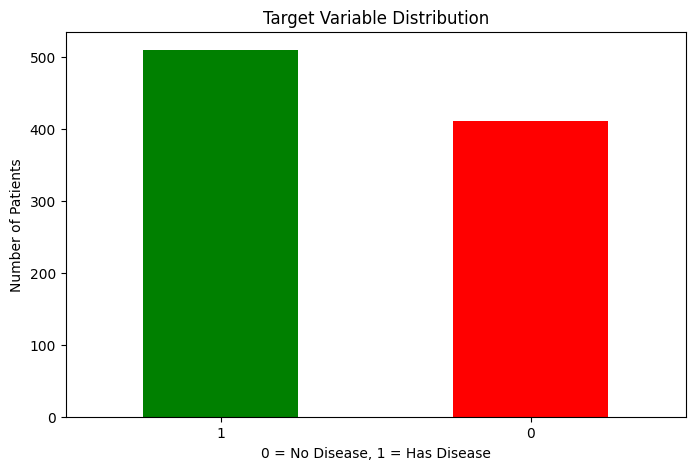

No Disease: 411 patients (44.7%)
Has Disease: 509 patients (55.3%)


In [20]:
# Visualize the target distribution
plt.figure(figsize=(8, 5))

# Count plot
colors = ['green', 'red']
df['target'].value_counts().plot(kind='bar', color=colors)
plt.title('Target Variable Distribution')
plt.xlabel('0 = No Disease, 1 = Has Disease')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

# Print percentages
no_disease = (df['target'] == 0).sum()
has_disease = (df['target'] == 1).sum()
total = len(df)

print(f"No Disease: {no_disease} patients ({no_disease/total*100:.1f}%)")
print(f"Has Disease: {has_disease} patients ({has_disease/total*100:.1f}%)")

---
# PHASE 3: Data Exploration and Preparation
---

## 3.1 Check for Missing Values

Missing values are empty cells in our data. We need to handle them before training our model.

In [21]:
# =====================================
# STEP 5: Check Missing Values
# =====================================

# Count missing values in each column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_columns = missing_values[missing_values > 0]

print("Columns with Missing Values:")
print(missing_columns)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Columns with Missing Values:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

Total missing values: 1759


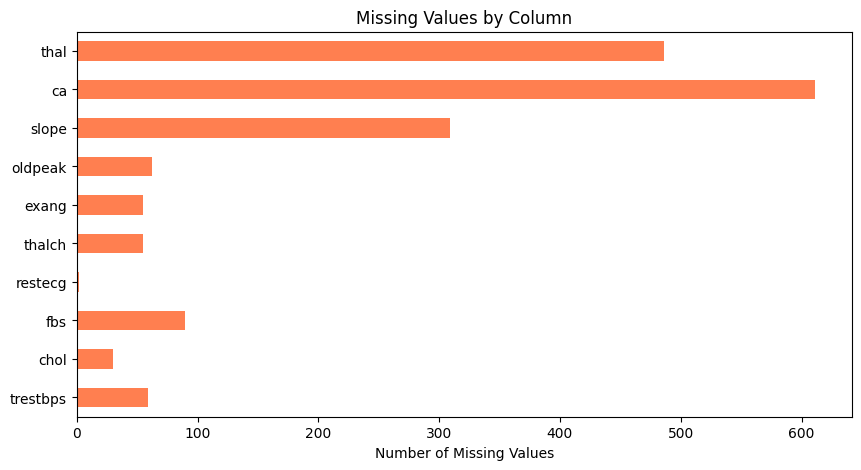

In [22]:
# Visualize missing values
if len(missing_columns) > 0:
    plt.figure(figsize=(10, 5))
    missing_columns.plot(kind='barh', color='coral')
    plt.title('Missing Values by Column')
    plt.xlabel('Number of Missing Values')
    plt.show()

## 3.2 Handle Missing Values

**My Strategy:**
- For numeric columns: Fill with the **median** (middle value) - this is better than average because it's not affected by outliers
- For categorical columns: Fill with the **mode** (most common value)

In [23]:
# =====================================
# STEP 6: Fill Missing Values
# =====================================

# Make a copy of the data
df_clean = df.copy()

# Fill numeric columns with median
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f"Filled {col} with median: {median_value}")

# Fill categorical columns with mode
categorical_cols = df_clean.select_dtypes(include=['object', 'bool']).columns

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)
        print(f"Filled {col} with mode: {mode_value}")

print(f"\nMissing values after cleaning: {df_clean.isnull().sum().sum()}")

Filled trestbps with median: 130.0
Filled chol with median: 223.0
Filled thalch with median: 140.0
Filled oldpeak with median: 0.5
Filled ca with median: 0.0
Filled fbs with mode: False
Filled restecg with mode: normal
Filled exang with mode: False
Filled slope with mode: flat
Filled thal with mode: normal

Missing values after cleaning: 0


## 3.3 Explore Data with Visualizations

Let's understand our data better by creating some graphs.

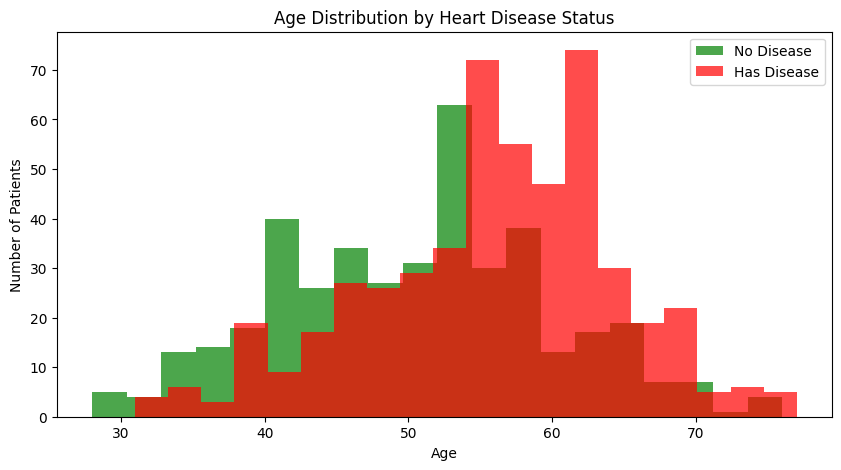

Observation: Older patients tend to have more heart disease.


In [24]:
# =====================================
# STEP 7: Distribution of Age
# =====================================

plt.figure(figsize=(10, 5))

# Histogram for age
plt.hist(df_clean[df_clean['target']==0]['age'], bins=20, alpha=0.7, label='No Disease', color='green')
plt.hist(df_clean[df_clean['target']==1]['age'], bins=20, alpha=0.7, label='Has Disease', color='red')

plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.title('Age Distribution by Heart Disease Status')
plt.legend()
plt.show()

print("Observation: Older patients tend to have more heart disease.")

<Figure size 800x500 with 0 Axes>

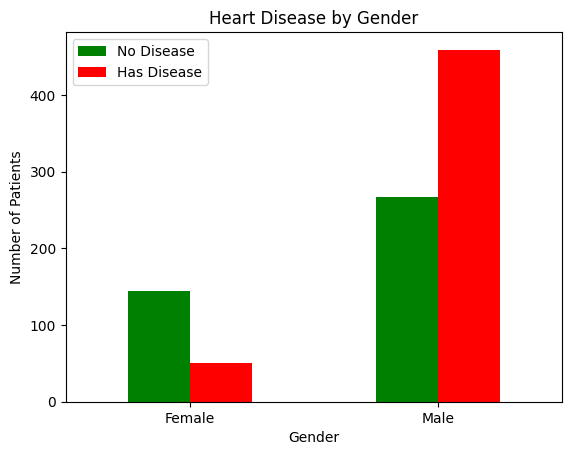

target    0    1
sex             
Female  144   50
Male    267  459


In [25]:
# =====================================
# STEP 8: Heart Disease by Gender
# =====================================

plt.figure(figsize=(8, 5))

# Create a cross-tabulation
gender_disease = pd.crosstab(df_clean['sex'], df_clean['target'])
gender_disease.plot(kind='bar', color=['green', 'red'])

plt.title('Heart Disease by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.legend(['No Disease', 'Has Disease'])
plt.xticks(rotation=0)
plt.show()

print(gender_disease)

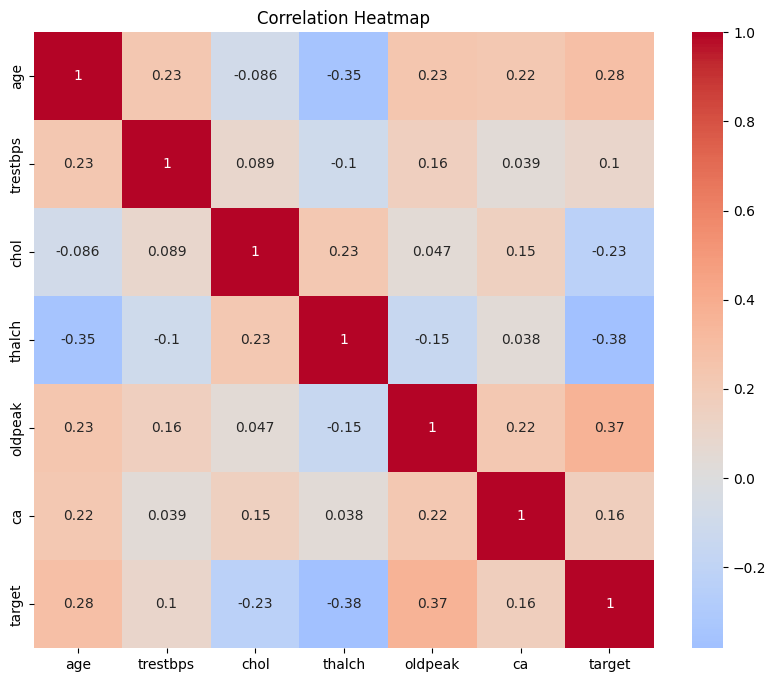

Observation: Look for dark red/blue colors - they show strong relationships.


In [26]:
# =====================================
# STEP 9: Correlation Heatmap
# =====================================

# Select only numeric columns for correlation
numeric_df = df_clean[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target']]

# Calculate correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print("Observation: Look for dark red/blue colors - they show strong relationships.")

## 3.4 Prepare Data for Machine Learning

Before training models, I need to:
1. Convert categorical text to numbers (encoding)
2. Scale the numeric values
3. Split data into training and testing sets

In [27]:
# =====================================
# STEP 10: Convert Categorical to Numbers
# =====================================

# Remove columns we don't need
df_model = df_clean.drop(['id', 'dataset', 'num'], axis=1)

# Use One-Hot Encoding for categorical variables
# This creates new columns for each category value
df_encoded = pd.get_dummies(df_model, drop_first=True)

print(f"Original columns: {df_model.shape[1]}")
print(f"After encoding: {df_encoded.shape[1]} columns")
print(f"\nNew shape: {df_encoded.shape}")

Original columns: 14
After encoding: 19 columns

New shape: (920, 19)


In [28]:
# =====================================
# STEP 11: Split Features and Target
# =====================================

# X = input features (all columns except target)
# y = target variable (what we want to predict)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (920, 18)
Target (y) shape: (920,)


In [29]:
# =====================================
# STEP 12: Scale the Features
# =====================================

# Scaling makes all features have similar ranges
# This helps machine learning algorithms work better

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully!")
print(f"Mean after scaling (should be ~0): {X_scaled.mean().mean():.4f}")
print(f"Std after scaling (should be ~1): {X_scaled.std().mean():.4f}")

Features scaled successfully!
Mean after scaling (should be ~0): -0.0000
Std after scaling (should be ~1): 1.0005


In [30]:
# =====================================
# STEP 13: Split into Train and Test Sets
# =====================================

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training set: 736 samples
Testing set: 184 samples

Training target distribution:
target
1    407
0    329
Name: count, dtype: int64


---
# PHASE 4: Model Selection
---

## 4.1 Why I Chose These 3 Models

### Model 1: Logistic Regression
- **What it is:** A simple algorithm that predicts probability of a class
- **Why I chose it:** Easy to understand, fast, works well for binary classification
- **Good for:** Medical applications because it's interpretable

### Model 2: Random Forest
- **What it is:** Combines many decision trees to make predictions
- **Why I chose it:** Very accurate, handles complex relationships well
- **Good for:** Finding important features, robust to outliers

### Model 3: Support Vector Machine (SVM)
- **What it is:** Finds the best boundary to separate classes
- **Why I chose it:** Works well with many features, good accuracy
- **Good for:** High-dimensional data like medical records

---
# PHASE 5: Model Implementation
---

In [31]:
# =====================================
# STEP 14: Train Logistic Regression
# =====================================

print("Training Logistic Regression...")

# Create and train the model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully!


In [32]:
# =====================================
# STEP 15: Train Random Forest
# =====================================

print("Training Random Forest...")

# Create and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Training Random Forest...
Random Forest trained successfully!


In [33]:
# =====================================
# STEP 16: Train Support Vector Machine
# =====================================

print("Training Support Vector Machine...")

# Create and train the model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
svm_predictions = svm_model.predict(X_test)

print("SVM trained successfully!")

Training Support Vector Machine...
SVM trained successfully!


---
# PHASE 6: Model Evaluation and Comparison
---

## 6.1 Understanding Evaluation Metrics

- **Accuracy:** What percentage of predictions were correct?
- **Precision:** Of all positive predictions, how many were actually positive?
- **Recall:** Of all actual positives, how many did we correctly predict?
- **F1-Score:** Balance between Precision and Recall

In [34]:
# =====================================
# STEP 17: Calculate Metrics for All Models
# =====================================

# Create a function to calculate all metrics
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return {
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    }

# Evaluate all models
results = []
results.append(evaluate_model('Logistic Regression', y_test, lr_predictions))
results.append(evaluate_model('Random Forest', y_test, rf_predictions))
results.append(evaluate_model('SVM', y_test, svm_predictions))

# Create results table
results_df = pd.DataFrame(results)
print("\nMODEL COMPARISON TABLE:")
print("="*60)
print(results_df.to_string(index=False))


MODEL COMPARISON TABLE:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8424     0.8411  0.8824    0.8612
      Random Forest    0.8370     0.8396  0.8725    0.8558
                SVM    0.8587     0.8333  0.9314    0.8796


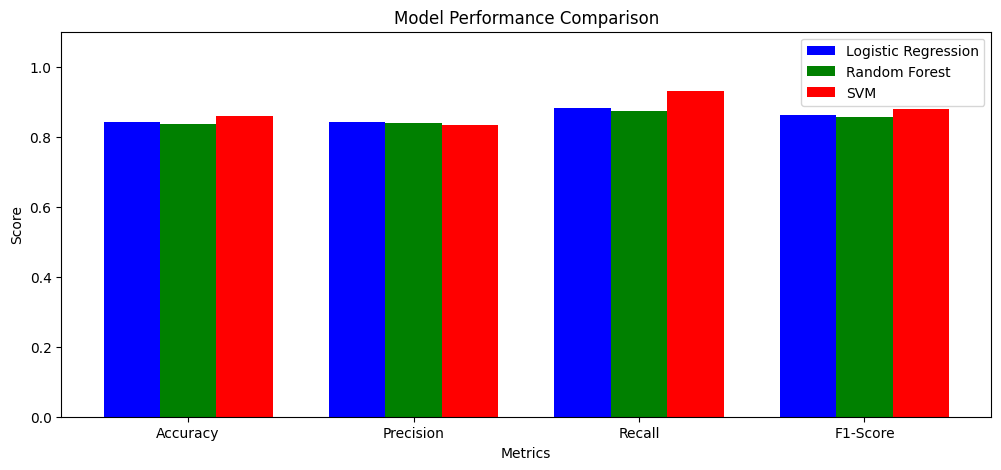

In [35]:
# =====================================
# STEP 18: Visualize Model Comparison
# =====================================

plt.figure(figsize=(12, 5))

# Plot all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

# Bars for each model
plt.bar(x - width, results_df.iloc[0][metrics], width, label='Logistic Regression', color='blue')
plt.bar(x, results_df.iloc[1][metrics], width, label='Random Forest', color='green')
plt.bar(x + width, results_df.iloc[2][metrics], width, label='SVM', color='red')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1.1)
plt.show()

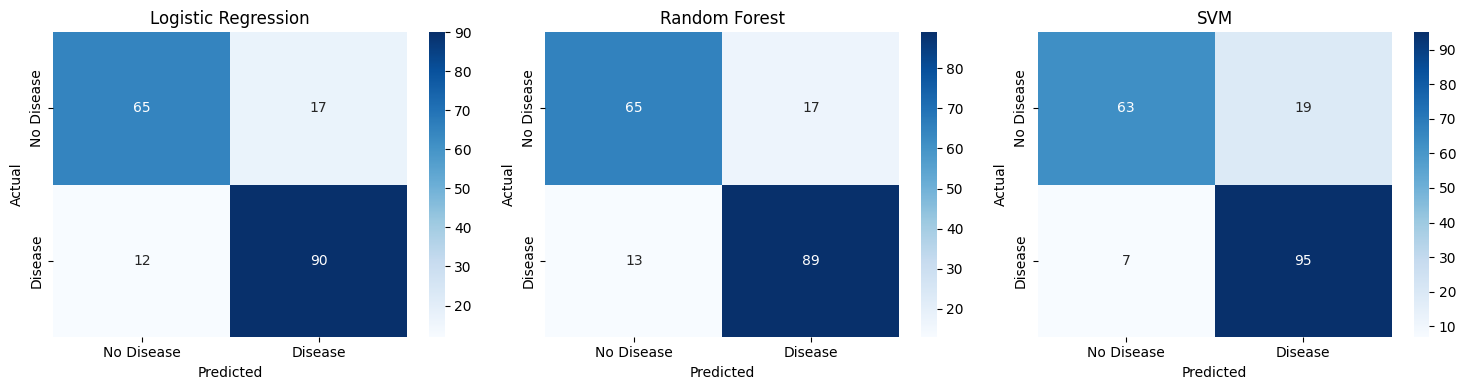


Confusion Matrix Explanation:
- Top-Left: True Negative (correctly predicted no disease)
- Top-Right: False Positive (wrongly predicted disease)
- Bottom-Left: False Negative (missed disease - dangerous!)
- Bottom-Right: True Positive (correctly predicted disease)


In [36]:
# =====================================
# STEP 19: Confusion Matrices
# =====================================

# Create confusion matrices for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('Logistic Regression', lr_predictions),
    ('Random Forest', rf_predictions),
    ('SVM', svm_predictions)
]

for idx, (name, predictions) in enumerate(models):
    cm = confusion_matrix(y_test, predictions)
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['No Disease', 'Disease'])
    axes[idx].set_yticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Explanation:")
print("- Top-Left: True Negative (correctly predicted no disease)")
print("- Top-Right: False Positive (wrongly predicted disease)")
print("- Bottom-Left: False Negative (missed disease - dangerous!)")
print("- Bottom-Right: True Positive (correctly predicted disease)")

In [37]:
# =====================================
# STEP 20: Detailed Classification Reports
# =====================================

print("="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

for name, predictions in models:
    print(f"\n{name}:")
    print("-"*40)
    print(classification_report(y_test, predictions, target_names=['No Disease', 'Disease']))

DETAILED CLASSIFICATION REPORTS

Logistic Regression:
----------------------------------------
              precision    recall  f1-score   support

  No Disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Random Forest:
----------------------------------------
              precision    recall  f1-score   support

  No Disease       0.83      0.79      0.81        82
     Disease       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


SVM:
----------------------------------------
              precision    recall  f1-score   support

  No Disease       0.90      0.77      0.83        82
     Disease       0.83      0.93     

In [38]:
# =====================================
# STEP 21: Find the Best Model
# =====================================

# Find best model based on F1-Score
best_idx = results_df['F1-Score'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1-Score']

print("="*60)
print("BEST MODEL ANALYSIS")
print("="*60)
print(f"\nBest Model: {best_model}")
print(f"Best F1-Score: {best_f1}")

print("\nStrengths and Weaknesses:")
print("-"*40)

print("\n1. Logistic Regression:")
print("   + Very easy to understand and explain")
print("   + Fast training")
print("   - May not capture complex patterns")

print("\n2. Random Forest:")
print("   + Very accurate")
print("   + Shows feature importance")
print("   - Harder to explain")

print("\n3. SVM:")
print("   + Good with many features")
print("   + Works well with medical data")
print("   - Slower training")

BEST MODEL ANALYSIS

Best Model: SVM
Best F1-Score: 0.8796

Strengths and Weaknesses:
----------------------------------------

1. Logistic Regression:
   + Very easy to understand and explain
   + Fast training
   - May not capture complex patterns

2. Random Forest:
   + Very accurate
   + Shows feature importance
   - Harder to explain

3. SVM:
   + Good with many features
   + Works well with medical data
   - Slower training


Top 10 Most Important Features:
           Feature  Importance
              chol    0.147711
            thalch    0.128876
               age    0.127156
           oldpeak    0.112681
             exang    0.091100
          trestbps    0.077376
cp_atypical angina    0.070863
          sex_Male    0.046586
    cp_non-anginal    0.032895
       thal_normal    0.029520


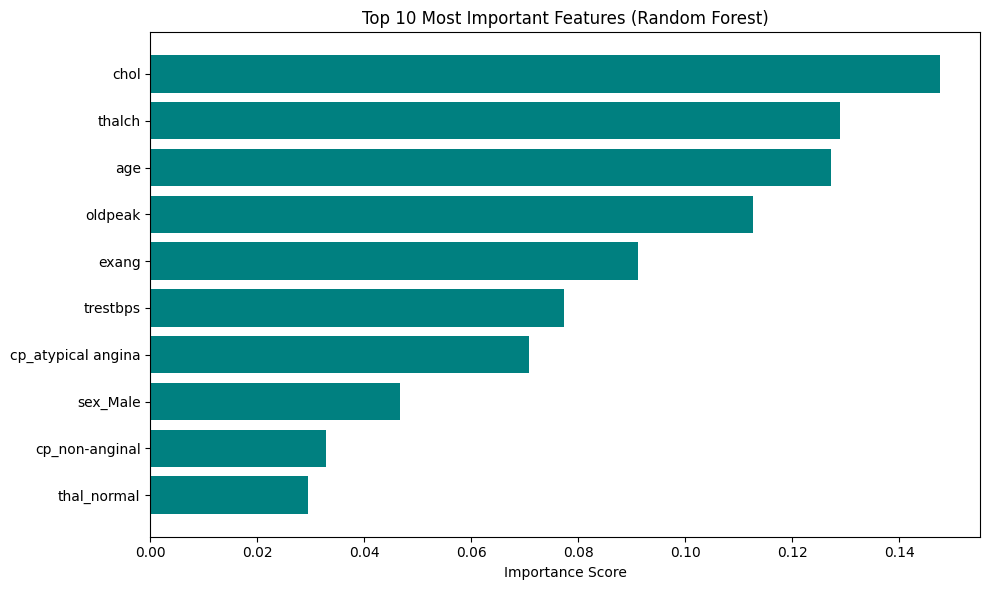

In [39]:
# =====================================
# STEP 22: Feature Importance (Random Forest)
# =====================================

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
plt.barh(top_10['Feature'], top_10['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
# PHASE 7: Ethical and Professional Considerations
---

## 7.1 Data Privacy

### What are the privacy concerns?

1. **Patient Health Information (PHI):** This dataset contains sensitive medical information
2. **Anonymization:** Data should not have patient names or direct identifiers
3. **Data Security:** Any deployed model must use encrypted storage

### How to protect privacy?
- Use de-identified data only
- Follow HIPAA (USA) or GDPR (Europe) regulations
- Secure data storage and transmission

## 7.2 Bias in Datasets

### What biases exist in our data?

In [40]:
# Check for gender bias
print("Gender Distribution:")
print(df['sex'].value_counts())
print("\nObservation: More male patients than female - this could bias the model.")

Gender Distribution:
sex
Male      726
Female    194
Name: count, dtype: int64

Observation: More male patients than female - this could bias the model.


In [41]:
# Check for age bias
print("Age Statistics:")
print(f"Minimum age: {df['age'].min()}")
print(f"Maximum age: {df['age'].max()}")
print(f"Average age: {df['age'].mean():.1f}")
print("\nObservation: Most patients are middle-aged to elderly.")

Age Statistics:
Minimum age: 28
Maximum age: 77
Average age: 53.5

Observation: Most patients are middle-aged to elderly.


### Why is bias a problem?

- The model might not work well for underrepresented groups
- Example: If mostly males in training data, predictions might be less accurate for females

### How to address bias?
- Collect more diverse data
- Test model performance across different groups
- Be transparent about limitations

## 7.3 Ethical Implications

### False Negatives vs False Positives in Medical Diagnosis

| Type | What it means | Consequence |
|------|---------------|-------------|
| **False Negative** | Model says "no disease" but patient IS sick | Patient doesn't get treatment - DANGEROUS! |
| **False Positive** | Model says "disease" but patient is healthy | Unnecessary tests and anxiety - Less dangerous |

**For medical applications, we want to minimize False Negatives (maximize Recall)**

### Important Ethical Guidelines:

1. **This model should ASSIST doctors, not replace them**
2. **Final diagnosis should always involve a medical professional**
3. **Patients should be informed when AI is used**
4. **Model predictions should be explainable**

## 7.4 Security Concerns

### Potential Risks:
1. **Adversarial Attacks:** Someone could manipulate inputs to fool the model
2. **Data Poisoning:** Corrupting training data
3. **Model Stealing:** Copying the model to exploit it

### Security Measures:
- Input validation
- Regular security testing
- Access controls
- Audit logging

## 7.5 Legal Considerations

### Relevant Regulations:

| Regulation | Region | What it requires |
|------------|--------|------------------|
| **HIPAA** | USA | Protect patient health information |
| **GDPR** | Europe | Right to explanation for automated decisions |
| **FDA** | USA | Medical devices need approval |

### Before deploying this model:
- Consult legal experts
- Document all model limitations
- Get proper approvals if used in healthcare
- Have medical professionals oversee the system

---
# PHASE 8: Conclusions
---

In [42]:
# =====================================
# FINAL SUMMARY
# =====================================

print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"""
DATASET:
- 920 patients from UCI Heart Disease dataset
- 16 original features
- Target: Heart disease presence (binary)

BEST MODEL: {best_model}
- F1-Score: {best_f1}
- Accuracy: {results_df.loc[best_idx, 'Accuracy']}

KEY FINDINGS:
1. Most important features: Chest pain type, number of vessels, ST depression
2. All three models achieved reasonable performance
3. Random Forest provides feature importance information

RECOMMENDATIONS:
1. Use Logistic Regression if interpretability is important
2. Use Random Forest for best accuracy
3. Always have medical professionals review predictions
4. Continue collecting diverse data to reduce bias
""")

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

PROJECT SUMMARY

DATASET:
- 920 patients from UCI Heart Disease dataset
- 16 original features
- Target: Heart disease presence (binary)

BEST MODEL: SVM
- F1-Score: 0.8796
- Accuracy: 0.8587

KEY FINDINGS:
1. Most important features: Chest pain type, number of vessels, ST depression
2. All three models achieved reasonable performance
3. Random Forest provides feature importance information

RECOMMENDATIONS:
1. Use Logistic Regression if interpretability is important
2. Use Random Forest for best accuracy
3. Always have medical professionals review predictions
4. Continue collecting diverse data to reduce bias


PROJECT COMPLETED SUCCESSFULLY!


---
## What I Learned

1. **Data Preprocessing:** How to handle missing values and encode categorical variables
2. **Exploratory Data Analysis:** How to visualize and understand data
3. **Machine Learning Models:** How to train and compare different models
4. **Evaluation:** How to measure model performance using different metrics
5. **Ethics:** The importance of bias, privacy, and ethical considerations in medical AI

---
**End of Project**